#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Consumo de Álcool em Estudantes

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=blue>1. Imports

In [96]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew

## <font color=blue>2. Preparação do Dataset

### 2.1 Carregamento do dataset

Dataset público do UCI Machine Learning Repository com 395 estudantes do ensino médio em Portugal. Os dados incluem notas, hábitos sociais, suporte familiar e consumo de álcool em dias úteis e finais de semana, etc.

Fonte: [Kaggle — Student Alcohol Consumption](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption)

In [97]:
# constantes que guardam o path de cada arquivo
STUDENT_CSV = (
    "/home/heitor/Documentos/MBA/01_estatistica/01_estatistica-student_alcohol/Student_Alcohol.csv"
)

# criei 2 jsons para o map das variáveis qualitativas.
COLUNAS_JSON = (
    "/home/heitor/Documentos/MBA/01_estatistica/01_estatistica-student_alcohol/colunas_pt.json"
)
VALORES_JSON = (
    "/home/heitor/Documentos/MBA/01_estatistica/01_estatistica-student_alcohol/valores_pt.json"
)

with open(COLUNAS_JSON, encoding="utf-8") as f:
    colunas_pt = json.load(f)

with open(VALORES_JSON, encoding="utf-8") as f:
    valores_pt = json.load(f)


for col, mapping in valores_pt.items():
    if all(k.lstrip("-").isdigit() for k in mapping):
        valores_pt[col] = {int(k): v for k, v in mapping.items()}

df = pd.read_csv(STUDENT_CSV)
df = df.rename(columns=colunas_pt)
df = df.replace(valores_pt)

### 2.2 Visão geral do dataset

In [98]:
df.info()
df.head(5)
# df.to_csv('df_custom.csv')

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   escola                395 non-null    str   
 1   sexo                  395 non-null    str   
 2   idade                 395 non-null    int64 
 3   endereco              395 non-null    str   
 4   tamanho familia       395 non-null    str   
 5   status pais           395 non-null    str   
 6   educ. mae             395 non-null    object
 7   educ. pai             395 non-null    object
 8   emprego mae           395 non-null    str   
 9   emprego pai           395 non-null    str   
 10  motivo escola         395 non-null    str   
 11  responsavel           395 non-null    str   
 12  tempo viagem          395 non-null    object
 13  tempo estudo          395 non-null    object
 14  reprovacoes           395 non-null    object
 15  suporte escola        395 non-null    str   
 16  s

,escola,sexo,idade,endereco,tamanho familia,status pais,educ. mae,educ. pai,emprego mae,emprego pai,...,relacao familiar,tempo livre,sair com amigos,alcool dia util,alcool fim semana,saude,faltas,nota periodo 1,nota periodo 2,nota final
0,gabriel pereira,feminino,18,urbano,>3 pessoas,separados,superior,superior,do lar,professor(a),...,boa,medio,bastante,muito baixo,muito baixo,regular,6,5,6,6
1,gabriel pereira,feminino,17,urbano,>3 pessoas,juntos,fund. i,fund. i,do lar,outro,...,excelente,medio,medio,muito baixo,muito baixo,regular,4,5,5,6
2,gabriel pereira,feminino,15,urbano,<=3 pessoas,juntos,fund. i,fund. i,do lar,outro,...,boa,medio,pouco,baixo,medio,regular,10,7,8,10
3,gabriel pereira,feminino,15,urbano,>3 pessoas,juntos,superior,fund. ii,saude,servicos,...,regular,pouco,pouco,muito baixo,muito baixo,muito boa,2,15,14,15
4,gabriel pereira,feminino,16,urbano,>3 pessoas,juntos,ensino medio,ensino medio,outro,outro,...,boa,medio,pouco,muito baixo,baixo,muito boa,4,6,10,10


## <font color=blue>3. Análise Exploratória

meu codigo vai ter muita linha estetica que nao necessariamente precisa ter. <br>
como eu aprendi a plotar de um jeito diferente do professor, <br>
eu preciso fazer certos ajustes a mais que o prof não faz, mas puramente estética. <br>
por exemplo:

`axes[1].set_ylim(0, contagem_endereco_pct.max() * 1.30)`

coloquei apenas para aumentar o eixo y e ele chegar ao 100%.


### 3.1 Distribuição por Endereço

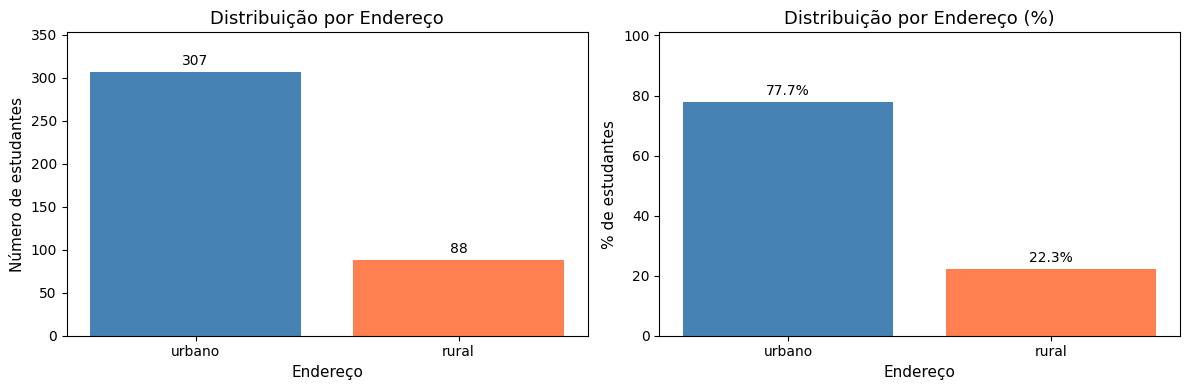

In [99]:
contagem_endereco = df["endereco"].value_counts()
contagem_endereco_pct = df["endereco"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    contagem_endereco.index, contagem_endereco.values, color=["steelblue", "coral"]
)
axes[0].set_xlabel("Endereço", fontsize=11)
axes[0].set_ylabel("Número de estudantes", fontsize=11)
axes[0].set_title("Distribuição por Endereço", fontsize=13)
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_ylim(0, contagem_endereco.max() * 1.15)

bars = axes[1].bar(
    contagem_endereco_pct.index,
    contagem_endereco_pct.values,
    color=["steelblue", "coral"],
)
axes[1].set_xlabel("Endereço", fontsize=11)
axes[1].set_ylabel("% de estudantes", fontsize=11)
axes[1].set_title("Distribuição por Endereço (%)", fontsize=13)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
axes[1].set_ylim(0, contagem_endereco_pct.max() * 1.30)

plt.tight_layout()
plt.show()

**observações:**
- a amostra é majoritariamente `urbana`: 77.7% (307) vs 22.3% `rural` (88)
- a desproporção limita comparações com valores absolutos entre os grupos. usar valores relativos como professor falou será mais útil
- levar em consideração que, por ter poucos dados de uma categoria, as análises podem não ser precisas

### 3.2 Consumo de Álcool em Dias Úteis

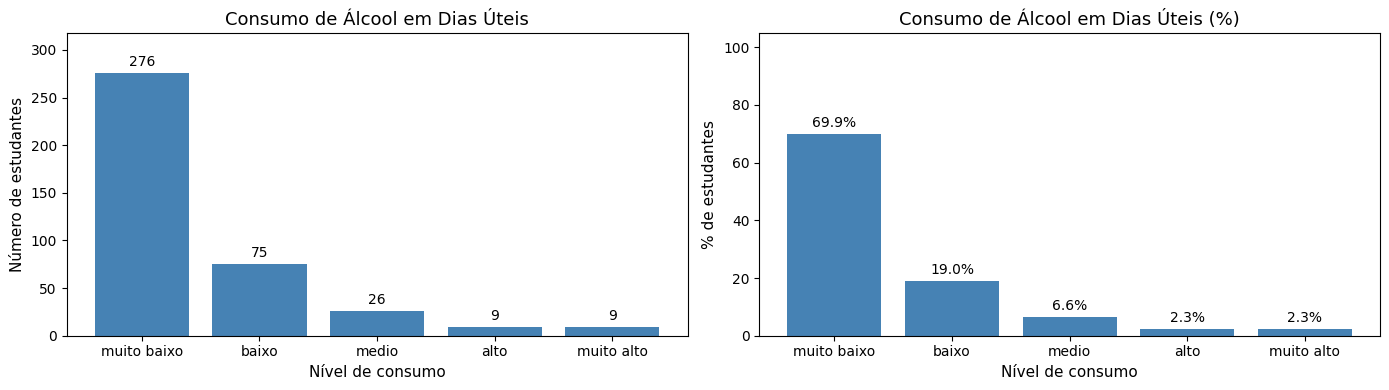

In [100]:
ordem_alcool = ["muito baixo", "baixo", "medio", "alto", "muito alto"]
contagem_alcool = (
    df["alcool dia util"].value_counts().reindex(ordem_alcool, fill_value=0)
)
contagem_alcool_pct = (
    df["alcool dia util"]
    .value_counts(normalize=True)
    .reindex(ordem_alcool, fill_value=0)
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(contagem_alcool.index, contagem_alcool.values, color="steelblue")
axes[0].set_xlabel("Nível de consumo", fontsize=11)
axes[0].set_ylabel("Número de estudantes", fontsize=11)
axes[0].set_title("Consumo de Álcool em Dias Úteis", fontsize=13)
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_ylim(0, contagem_alcool.max() * 1.15)

bars = axes[1].bar(
    contagem_alcool_pct.index, contagem_alcool_pct.values, color="steelblue"
)
axes[1].set_xlabel("Nível de consumo", fontsize=11)
axes[1].set_ylabel("% de estudantes", fontsize=11)
axes[1].set_title("Consumo de Álcool em Dias Úteis (%)", fontsize=13)
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
axes[1].set_ylim(0, contagem_alcool_pct.max() * 1.50)

plt.tight_layout()
plt.show()

**observações:**
- o consumo em dias úteis é concentrado nos níveis baixos: 69.9% `muito baixo` e 19.0% `baixo`
- apenas 10.7% dos estudantes consome `médio ou mais` em dias úteis
- `distribuição assimétrica à direita`. esperado para consumo em dias de semana (graças a deus)

### 3.3 Consumo por Endereço

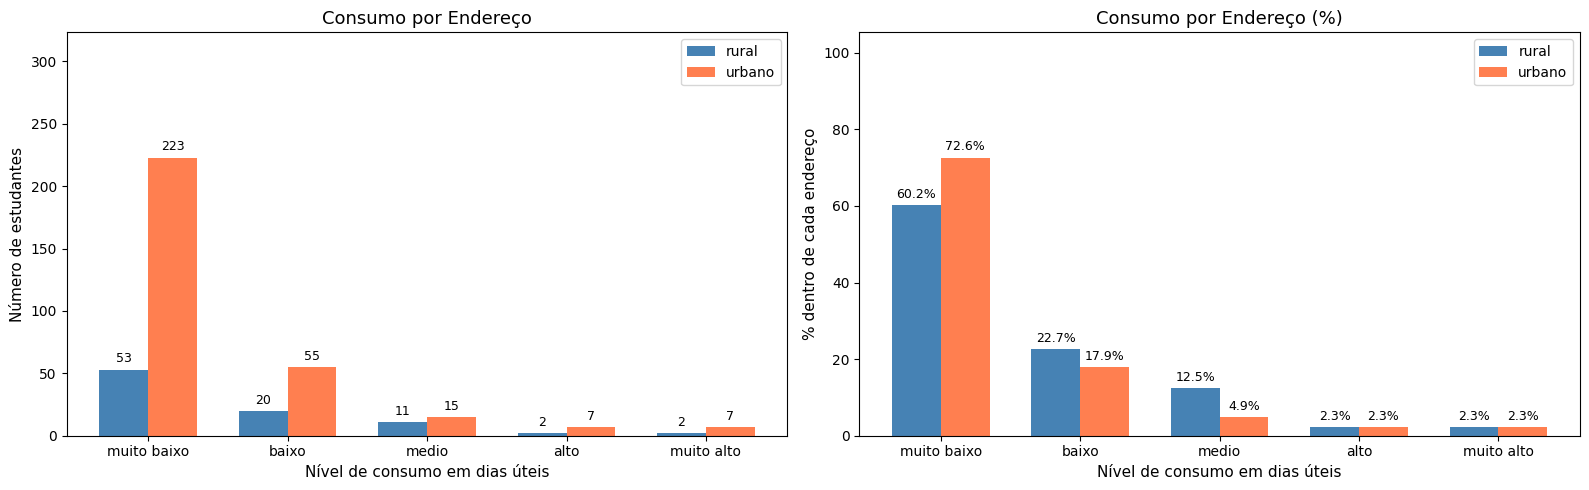

In [101]:
correlacao = (
    df.groupby(["endereco", "alcool dia util"])
    .size()
    .unstack("endereco")
    .reindex(ordem_alcool, fill_value=0)
)
correlacao_pct = correlacao / correlacao.sum() * 100

x = np.arange(len(ordem_alcool))
largura = 0.35
cores = ["steelblue", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dados, ylabel, fmt in [
    (axes[0], correlacao, "Número de estudantes", None),
    (axes[1], correlacao_pct, "% dentro de cada endereço", "%.1f%%"),
]:
    for i, (endereco, cor) in enumerate(zip(dados.columns, cores)):
        bars = ax.bar(
            x + i * largura - largura / 2,
            dados[endereco],
            largura,
            label=endereco,
            color=cor,
        )
        ax.bar_label(bars, fmt=fmt if fmt else "%d", padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_alcool, fontsize=10)
    ax.set_xlabel("Nível de consumo em dias úteis", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, dados.values.max() * 1.45)
    ax.legend(fontsize=10)

axes[0].set_title("Consumo por Endereço", fontsize=13)
axes[1].set_title("Consumo por Endereço (%)", fontsize=13)

plt.tight_layout()
plt.show()

**observações:**
- estudantes rurais apresentam consumo visivelmente maior: 12.5% no `nível médio` vs 4.9% urbano
- o `nível muito baixo` é maioria nos dois grupos, mas mais concentrado no urbano (72.6% vs 60.2%)
- os `níveis alto e muito alto` são equivalentes entre os grupos (~2.3% cada)

### 3.4 Consumo por Status dos Pais

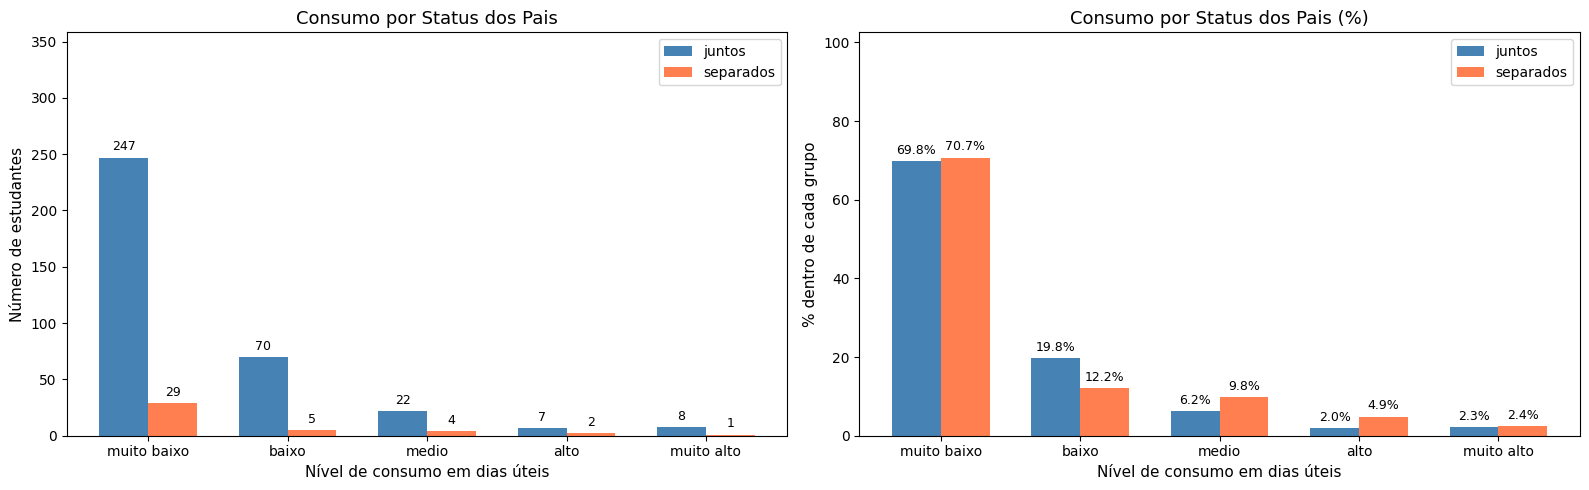

In [102]:
correlacao_pais = (
    df.groupby(["status pais", "alcool dia util"])
    .size()
    .unstack("status pais")
    .reindex(ordem_alcool, fill_value=0)
)
correlacao_pais_pct = correlacao_pais / correlacao_pais.sum() * 100

x = np.arange(len(ordem_alcool))
largura = 0.35
cores = ["steelblue", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dados, ylabel, fmt in [
    (axes[0], correlacao_pais, "Número de estudantes", None),
    (axes[1], correlacao_pais_pct, "% dentro de cada grupo", "%.1f%%"),
]:
    for i, (status, cor) in enumerate(zip(dados.columns, cores)):
        bars = ax.bar(
            x + i * largura - largura / 2,
            dados[status],
            largura,
            label=status,
            color=cor,
        )
        ax.bar_label(bars, fmt=fmt if fmt else "%d", padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_alcool, fontsize=10)
    ax.set_xlabel("Nível de consumo em dias úteis", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, dados.values.max() * 1.45)
    ax.legend(fontsize=10)

axes[0].set_title("Consumo por Status dos Pais", fontsize=13)
axes[1].set_title("Consumo por Status dos Pais (%)", fontsize=13)

plt.tight_layout()
plt.show()

**observações:**
- amostra de `pais separados` é pequena: apenas 41 estudantes (10.4%).
- `pais separados` concentram mais consumo médio/alto: 9.8% + 4.9% vs 6.2% + 2.0% entre os que `pais moram juntos`
- a diferença existe, porem são dados com poucas amostras da classe de `pais separados`

### 3.5 Nota Final × Tempo de Estudo por Nível de Álcool

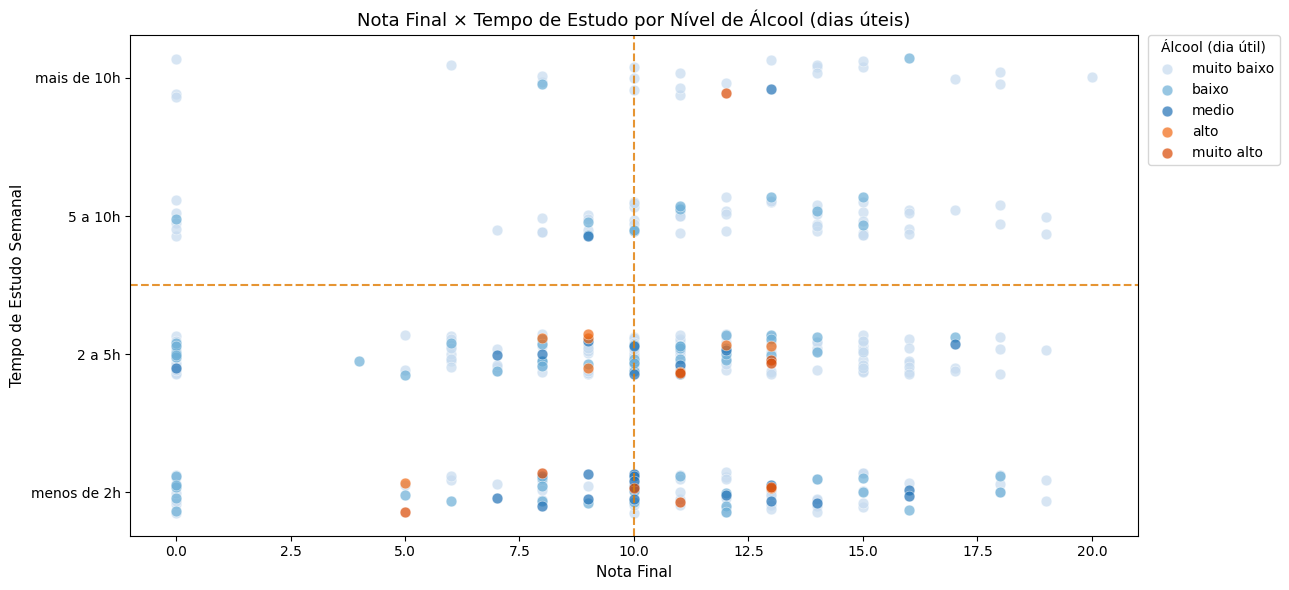

,N,Nota Média,Nota Mediana,Desvio Padrão,% Aprovados,Tempo de Estudo Médio (1–4)
Álcool em Dias Úteis,,,,,,
muito baixo,276,10.7,11,4.68,2.1%,69.93
baixo,75,9.3,10,4.81,1.9%,58.67
medio,26,10.5,10,3.44,1.5%,65.38
alto,9,9.9,9,2.62,1.8%,44.44
muito alto,9,10.7,11,2.69,1.7%,77.78


In [103]:
ordem_tempo_estudo = {"menos de 2h": 1, "2 a 5h": 2, "5 a 10h": 3, "mais de 10h": 4}
cores_alcool = {"muito baixo": "#c6dbef", "baixo": "#6baed6", "medio": "#2171b5", "alto": "#f16913", "muito alto": "#d94801"}

np.random.seed(42)
y_num = df["tempo estudo"].map(ordem_tempo_estudo)
y_jitter = y_num + np.random.uniform(-0.15, 0.15, size=len(df))

fig, ax = plt.subplots(figsize=(13, 6))

for nivel in ordem_alcool:
    mask = df["alcool dia util"] == nivel
    ax.scatter(
        df.loc[mask, "nota final"],
        y_jitter[mask],
        label=nivel,
        color=cores_alcool[nivel],
        alpha=0.7,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )

ax.axvline(10, linestyle="--", color="#e07b00", alpha=0.8, linewidth=1.5)
ax.axhline(2.5, linestyle="--", color="#e07b00", alpha=0.8, linewidth=1.5)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["menos de 2h", "2 a 5h", "5 a 10h", "mais de 10h"], fontsize=10)
ax.set_xlabel("Nota Final", fontsize=11)
ax.set_ylabel("Tempo de Estudo Semanal", fontsize=11)
ax.set_title("Nota Final × Tempo de Estudo por Nível de Álcool (dias úteis)", fontsize=13)
ax.legend(title="Álcool (dia útil)", fontsize=10, title_fontsize=10, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()
df_tab = df.copy()
df_tab["tempo estudo num"] = df_tab["tempo estudo"].map(ordem_tempo_estudo)
df_tab["aprovado"] = df_tab["nota final"] >= 10

tabela_resumo = (
    df_tab.groupby("alcool dia util", sort=False)
    .agg(
        N=("nota final", "count"),
        Nota_Media=("nota final", "mean"),
        Nota_Mediana=("nota final", "median"),
        Nota_DP=("nota final", "std"),
        Pct_Aprovados=("aprovado", "mean"),
        Tempo_Estudo_Medio=("tempo estudo num", "mean"),
    )
    .reindex(ordem_alcool)
)

tabela_resumo["% Aprovados"] = tabela_resumo["Pct_Aprovados"] * 100
tabela_resumo = tabela_resumo.drop(columns=["Pct_Aprovados"])
tabela_resumo.columns = ["N", "Nota Média", "Nota Mediana", "Desvio Padrão", "% Aprovados", "Tempo de Estudo Médio (1–4)"]
tabela_resumo.index.name = "Álcool em Dias Úteis"

display(
    tabela_resumo.style.format(
        {
            "N": "{:,.0f}",
            "Nota Média": "{:.1f}",
            "Nota Mediana": "{:.0f}",
            "Desvio Padrão": "{:.2f}",
            "% Aprovados": "{:.1f}%",
            "Tempo de Estudo Médio (1–4)": "{:.2f}",
        }
    ).set_caption("Tabela 3.1 — Nota Final e Tempo de Estudo por Nível de Álcool em Dias Úteis")
)

**observações:**
- quem consome menos álcool em dias úteis também estuda mais (tempo médio 2.14 vs abaixo de 1.88 nos demais níveis)
- o grupo `muito baixo` tem a maior taxa de aprovação (69.9%) e maior nota média (10.7)
- os grupos `alto e muito alto` somam apenas 18 estudantes.
- o desvio padrão alto nos grupos de baixo consumo indica alta variabilidade de desempenho mesmo entre quem bebe pouco

> **nota:** o treshold de aprovação adotado nesta análise é **nota final >= 10**, me baseei na escala portuguesa de 0 a 20 pontos, onde 10 corresponde ao mínimo suficiente. achei a fonte abaixo que sustenta a conclusão.<br>
> fonte: [Escala de Classificação Portuguesa — DGES](https://www.dges.gov.pt/pt/pagina/escala-de-classificacao-portuguesa-0)

**conclusão:**
- o consumo de álcool em dias úteis não apresenta relação clara com a taxa de aprovação.
- estudantes com consumo muito baixo dedicam mais tempo aos estudos (média 2.14) em comparação aos demais grupos, todos abaixo de 1.88
- a nota média mais alta pertence ao grupo de consumo muito baixo (10.7), empatada com muito alto (10.7). os grupos intermediários ficam abaixo,<br>o que  enfraquece qualquer relação entre consumo e desempenho
- o efeito observado é comportamental: maior consumo está = a menos horas de estudo